In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv("../data/train_augmented.csv")
print(df.columns)
df.head()


Index(['plaintext', 'ciphertext', 'cipher_type', 'key', 'ciphertext_length',
       'avg_char_freq', 'unique_chars'],
      dtype='object')


,plaintext,ciphertext,cipher_type,key,ciphertext_length,avg_char_freq,unique_chars
0,this is a secret message number 0,ta 0h temn issegeurseirsame csb,rail_fence,5,33,2.200000,15
1,this is a secret message number 1,UEVT oT N PRDiORU ZyPFBDR KHNYRS 1,vigenere,bxn,34,1.619048,21
2,this is a secret message number 2,XLM MW E WjIGVX QIWWEKI RYQFIV 2,caesar,4,32,2.000000,16
3,this is a secret message number 3,t ac s b3hsi ertmaenme sseegur,rail_fence,3,31,2.066667,15
4,this is a secret message number 4,tsce rhi femrseene i ase sgub4s tam,rail_fence,4,35,2.187500,16


In [2]:
# Texts and labels
texts = df["ciphertext"].astype(str).tolist()
labels = df["cipher_type"].astype(str).tolist()

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

# Tokenize text
tokenizer = Tokenizer(char_level=True)  # since ciphers are character-based
tokenizer.fit_on_texts(texts)
X = tokenizer.texts_to_sequences(texts)
X = pad_sequences(X, padding="post")

vocab_size = len(tokenizer.word_index) + 1
print("Vocab size:", vocab_size)
print("Max sequence length:", X.shape[1])


Vocab size: 38
Max sequence length: 39


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=X.shape[1]),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


c:\Users\ASus\NeuralCrypt\ai-cryptanalyst\venv\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_train, y_train, epochs=10, batch_size=64, validation_split=0.2)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.3146 - loss: 1.3790 - val_accuracy: 0.6562 - val_loss: 1.2713
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6581 - loss: 1.0471 - val_accuracy: 0.7531 - val_loss: 0.4049
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7541 - loss: 0.4274 - val_accuracy: 0.7594 - val_loss: 0.3590
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7365 - loss: 0.4497 - val_accuracy: 0.7531 - val_loss: 0.3542
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7419 - loss: 0.4101 - val_accuracy: 0.7594 - val_loss: 0.3439
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7361 - loss: 0.3864 - val_accuracy: 0.7531 - val_loss: 0.3436
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7391 - loss: 0.3858 - val_accuracy: 0.7594 - val_loss: 0.3426
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7282 - loss: 0.3874 - val_accuracy: 0.7594 - v

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7538 - loss: 0.3533
Test Accuracy: 0.75


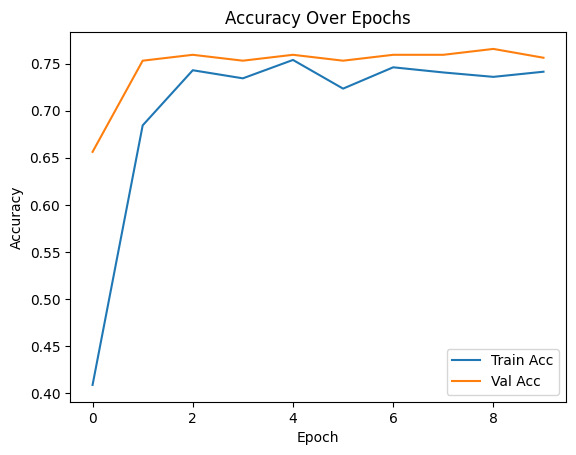

In [6]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")

# Plot training history
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.legend()
plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()


In [12]:
# Get all unique characters from ciphertexts
all_chars = sorted(set("".join(df["ciphertext"].tolist())))
char2idx = {c: i + 1 for i, c in enumerate(all_chars)}  # +1 to reserve 0 for padding
idx2char = {i: c for c, i in char2idx.items()}
vocab_size = len(char2idx) + 1  # +1 for padding token
max_len = df["ciphertext"].apply(len).max()


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# === Prepare Inputs ===
# Tokenize ciphertexts again if needed
X_seq = tf.keras.preprocessing.sequence.pad_sequences(
    df["ciphertext"].apply(lambda x: [char2idx.get(c, 0) for c in x]).tolist(),
    maxlen=max_len,
    padding="post"
)

# Normalize metadata
scaler = MinMaxScaler()
meta_features = df[["ciphertext_length", "avg_char_freq", "unique_chars"]]
X_meta = scaler.fit_transform(meta_features)

# Encode labels
y = tf.keras.utils.to_categorical(label_encoder.transform(df["cipher_type"]), num_classes=len(label_encoder.classes_))

# Train/val/test split
from sklearn.model_selection import train_test_split
X_seq_train, X_seq_test, X_meta_train, X_meta_test, y_train, y_test = train_test_split(
    X_seq, X_meta, y, test_size=0.2, random_state=42
)

# === Transformer Block ===
def transformer_encoder(inputs, head_size=64, num_heads=2, ff_dim=64, dropout=0.1):
    x = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + inputs)
    
    ffn = layers.Dense(ff_dim, activation="relu")(x)
    ffn = layers.Dense(inputs.shape[-1])(ffn)
    x = layers.Dropout(dropout)(ffn)
    return layers.LayerNormalization(epsilon=1e-6)(x + inputs)

# === Model Definition ===
# Sequence input
seq_input = Input(shape=(max_len,), name="cipher_seq")
embedding = layers.Embedding(input_dim=vocab_size, output_dim=64)(seq_input)
transformer_out = transformer_encoder(embedding)
x_seq = layers.GlobalAveragePooling1D()(transformer_out)

# Metadata input
meta_input = Input(shape=(X_meta.shape[1],), name="meta_input")

# Combine
x = layers.Concatenate()([x_seq, meta_input])
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)
output = layers.Dense(len(label_encoder.classes_), activation="softmax")(x)

model = Model(inputs=[seq_input, meta_input], outputs=output)
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ cipher_seq          │ (None, 39)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 39, 64)    │      4,096 │ cipher_seq[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 39, 64)    │     33,216 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 39, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 39, 64)    │          0 │ dropout_3[0][0],  │
│                     │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 39, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 39, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 39, 64)    │      4,160 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 39, 64)    │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 39, 64)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 39, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 67)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ meta_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,352 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 32)        │      2,080 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 4)         │        132 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 52,452 (204.89 KB)

 Trainable params: 52,452 (204.89 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    {"cipher_seq": X_seq_train, "meta_input": X_meta_train},
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

# Evaluate
test_loss, test_acc = model.evaluate({"cipher_seq": X_seq_test, "meta_input": X_meta_test}, y_test)
print(f"Test Accuracy: {test_acc:.2f}")


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5250 - loss: 1.0280 - val_accuracy: 0.7531 - val_loss: 0.3685
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7621 - loss: 0.4076 - val_accuracy: 0.8375 - val_loss: 0.3318
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7499 - loss: 0.3828 - val_accuracy: 0.7531 - val_loss: 0.3410
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7523 - loss: 0.3697 - val_accuracy: 0.7531 - val_loss: 0.3337
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7712 - loss: 0.3524 - val_accuracy: 0.7563 - val_loss: 0.3363
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7651 - loss: 0.3624 - val_accuracy: 0.8094 - val_loss: 0.3294
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7680 - loss: 0.3461 - val_accuracy: 0.8125 - val_loss: 0.3146
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7822 - loss: 0.3360 - val_accuracy: 0.8500 - v

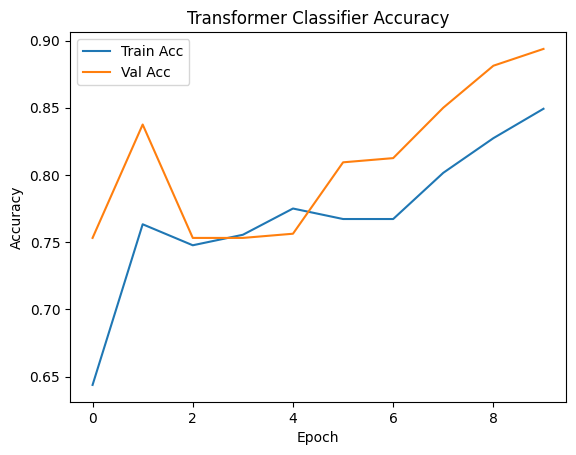

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Transformer Classifier Accuracy")
plt.legend()
plt.show()


In [16]:
import random

def corrupt_text(text, prob=0.1):
    chars = list(text)
    i = 0
    while i < len(chars):
        if random.random() < prob:
            op = random.choice(['swap', 'delete', 'insert'])
            if op == 'swap' and i < len(chars) - 1:
                chars[i], chars[i+1] = chars[i+1], chars[i]
                i += 1
            elif op == 'delete':
                chars.pop(i)
                continue
            elif op == 'insert':
                chars.insert(i, random.choice('abcdefghijklmnopqrstuvwxyz '))
                i += 1
        i += 1
    return ''.join(chars)


In [19]:
import random

def add_noise(text, p=0.1):
    noisy = []
    for c in text:
        if random.random() < p:
            if random.random() < 0.33:
                # Replace with random char
                noisy.append(random.choice("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ "))
            elif random.random() < 0.5:
                # Drop char
                continue
            else:
                # Duplicate char
                noisy.append(c)
                noisy.append(c)
        else:
            noisy.append(c)
    return "".join(noisy)

# Create the noisy version of ciphertext
df["ciphertext_noisy"] = df["ciphertext"].apply(lambda x: add_noise(x, p=0.1))


In [20]:
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# Init empty BPE model
tokenizer = Tokenizer(models.BPE())
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

# Prepare data
ciphertexts = df["ciphertext_noisy"].tolist()
trainer = trainers.BpeTrainer(vocab_size=100, show_progress=True)

tokenizer.train_from_iterator(ciphertexts, trainer=trainer)

# Save tokenizer if desired
# tokenizer.save("bpe_cipher_tokenizer.json")


In [21]:
X_bpe = [tokenizer.encode(txt).ids for txt in df["ciphertext_noisy"]]
max_bpe_len = max(len(seq) for seq in X_bpe)

from tensorflow.keras.preprocessing.sequence import pad_sequences
X_bpe_padded = pad_sequences(X_bpe, maxlen=max_bpe_len, padding='post')


In [22]:
def positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    # apply sin to even indices; cos to odd indices
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.cast(angle_rads, dtype=tf.float32)

positional_encodings = positional_encoding(max_bpe_len, 64)  # e.g., embedding dim 64
